# 03 — Análisis exploratorio (EDA)

Se trabaja sobre `data/processed/streaming_users_clean.csv`. Cada visualización responde a una de las
preguntas definidas en el notebook 01:

- **P1.** ¿Cómo se distribuye el tiempo de visualización mensual?
- **P2.** ¿Difiere el consumo entre planes de suscripción?
- **P3.** ¿Existe relación entre edad y tiempo de visualización?
- **P4.** ¿Las preferencias de género varían según el país?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/processed/streaming_users_clean.csv", parse_dates=["last_login_date"])
ORDEN_PLAN = ["Básico", "Estándar", "Premium"]
print(df.shape)

(8000, 9)


## Análisis univariado

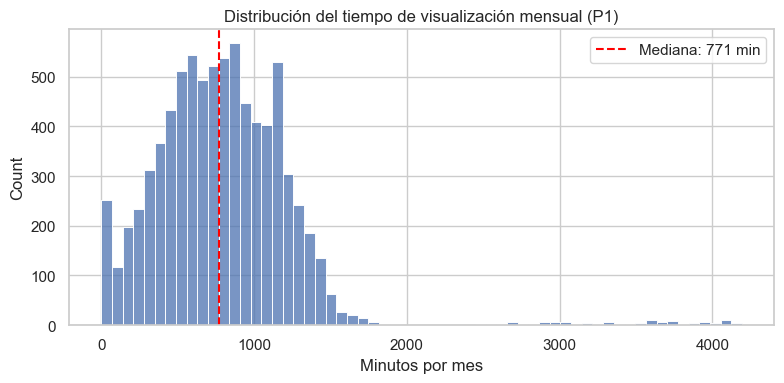

Asimetría (skew): 2.43


In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["monthly_watch_time_mins"], bins=60, ax=ax)
ax.axvline(df["monthly_watch_time_mins"].median(), color="red", linestyle="--",
           label=f"Mediana: {df['monthly_watch_time_mins'].median():.0f} min")
ax.set_title("Distribución del tiempo de visualización mensual (P1)")
ax.set_xlabel("Minutos por mes")
ax.legend()
plt.tight_layout()
plt.show()
print("Asimetría (skew):", round(df["monthly_watch_time_mins"].skew(), 2))

**Interpretación (P1):** la distribución es **asimétrica a la derecha** (skew ≈ 2,4): la mitad de los
usuarios consume hasta ~770 min/mes (~13 horas), pero existe una cola de usuarios intensivos que supera
los 3.000 min. Para el proyecto esto implica dos cosas: (a) la media no es representativa del usuario
típico —por eso en la limpieza se imputó con medianas—, y (b) el consumo no es homogéneo, lo que motiva
buscar qué lo diferencia (P2 y P3).

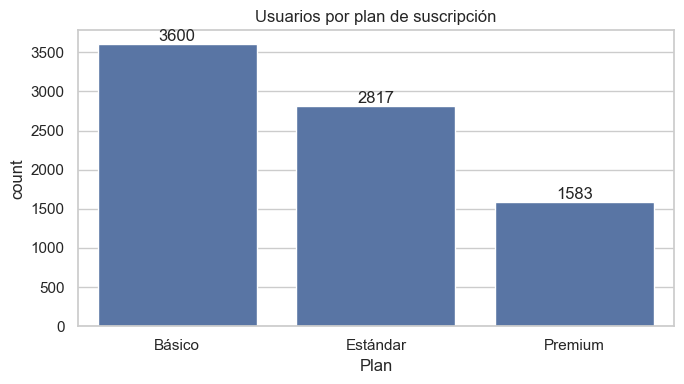

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="subscription_plan", order=ORDEN_PLAN, ax=ax)
for cont in ax.containers:
    ax.bar_label(cont)
ax.set_title("Usuarios por plan de suscripción")
ax.set_xlabel("Plan")
plt.tight_layout()
plt.show()

**Interpretación:** la base es mayormente de planes económicos: **Básico concentra el 45 %** de los
usuarios, Estándar el 35 % y Premium solo el 20 %. Esto contextualiza P2: cualquier diferencia de consumo
entre planes afecta a segmentos de tamaño muy distinto, y el segmento premium —el de mayor ingreso por
usuario— es el más chico.

## Análisis bivariado

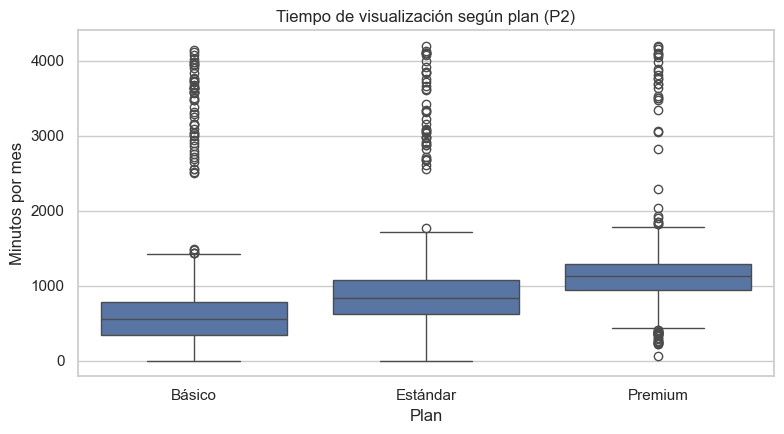

subscription_plan
Básico       552.7
Estándar     840.0
Premium     1127.0
Name: monthly_watch_time_mins, dtype: float64

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x="subscription_plan", y="monthly_watch_time_mins", order=ORDEN_PLAN, ax=ax)
ax.set_title("Tiempo de visualización según plan (P2)")
ax.set_xlabel("Plan")
ax.set_ylabel("Minutos por mes")
plt.tight_layout()
plt.show()
df.groupby("subscription_plan")["monthly_watch_time_mins"].median().reindex(ORDEN_PLAN).round(1)

**Interpretación (P2):** el consumo **escala claramente con el plan**: la mediana pasa de ~553 min
(Básico) a ~840 (Estándar) y ~1.127 (Premium), es decir, un usuario Premium típico mira **el doble**
que uno Básico. Es el hallazgo más fuerte del EDA: el plan contratado es el mejor diferenciador del
nivel de consumo disponible en el dataset.

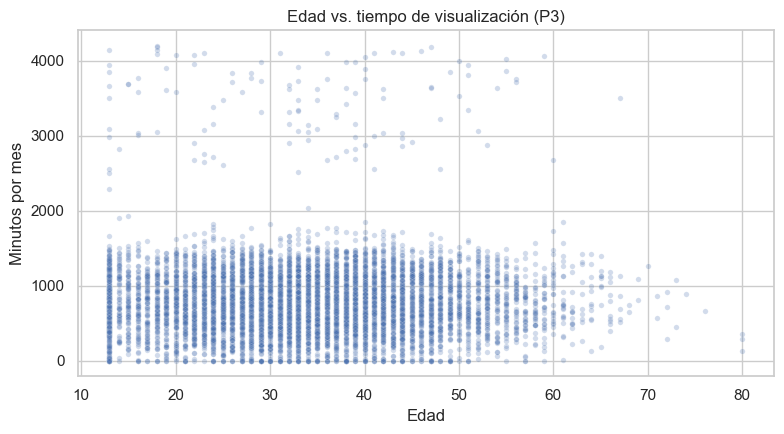

Correlación de Pearson edad-consumo: 0.006


In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.scatterplot(data=df, x="age", y="monthly_watch_time_mins", alpha=0.25, s=15, ax=ax)
ax.set_title("Edad vs. tiempo de visualización (P3)")
ax.set_xlabel("Edad")
ax.set_ylabel("Minutos por mes")
plt.tight_layout()
plt.show()
print("Correlación de Pearson edad-consumo:",
      round(df["age"].corr(df["monthly_watch_time_mins"]), 3))

**Interpretación (P3):** no hay relación entre edad y consumo: la nube de puntos no muestra tendencia y
la correlación es prácticamente nula (r ≈ 0,006). Es un resultado negativo pero informativo: la edad
**no** sirve para segmentar por intensidad de uso en esta plataforma; la segmentación útil pasa por el
plan (P2).

## Análisis multivariado

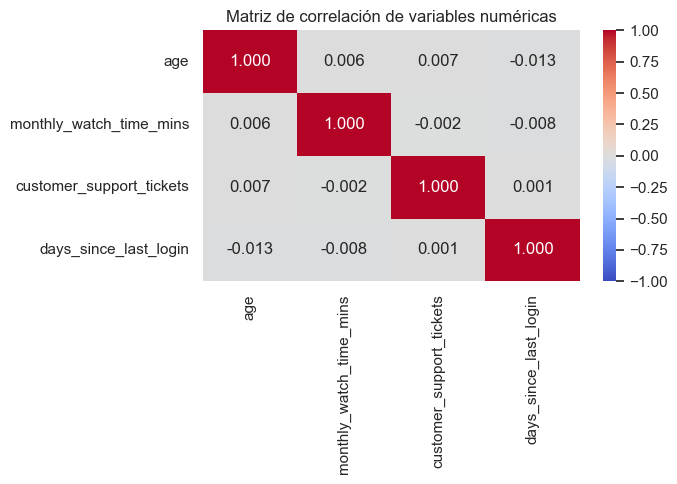

In [6]:
numericas = ["age", "monthly_watch_time_mins", "customer_support_tickets", "days_since_last_login"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numericas].corr(), annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

**Interpretación:** todas las correlaciones entre las numéricas son cercanas a cero (|r| < 0,02):
edad, consumo, tickets y recencia se comportan como dimensiones **independientes** del usuario.
Esto anticipa el resultado de PCA (P5, notebook 04): sin correlación no hay redundancia que comprimir.

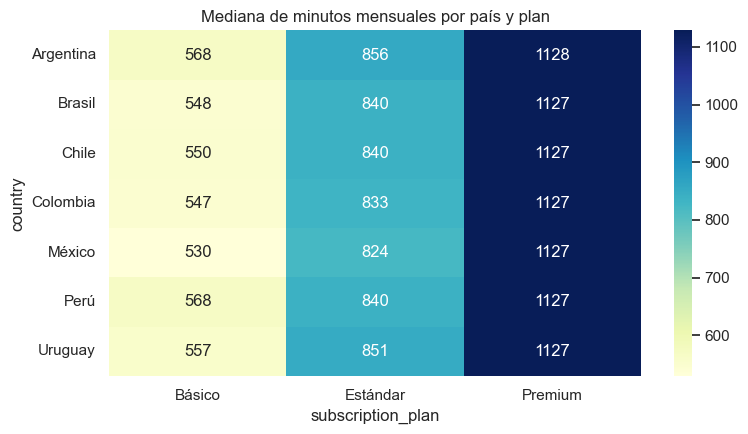

In [7]:
pivote = df.pivot_table(values="monthly_watch_time_mins", index="country",
                        columns="subscription_plan", aggfunc="median")[ORDEN_PLAN]
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(pivote, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax)
ax.set_title("Mediana de minutos mensuales por país y plan")
plt.tight_layout()
plt.show()

**Interpretación:** al cruzar país, plan y consumo se ve que el escalón Básico → Estándar → Premium se
repite **en los 7 países** con medianas muy similares (columnas casi uniformes). El efecto del plan es
general y no depende del mercado: no hay países con comportamiento atípico.

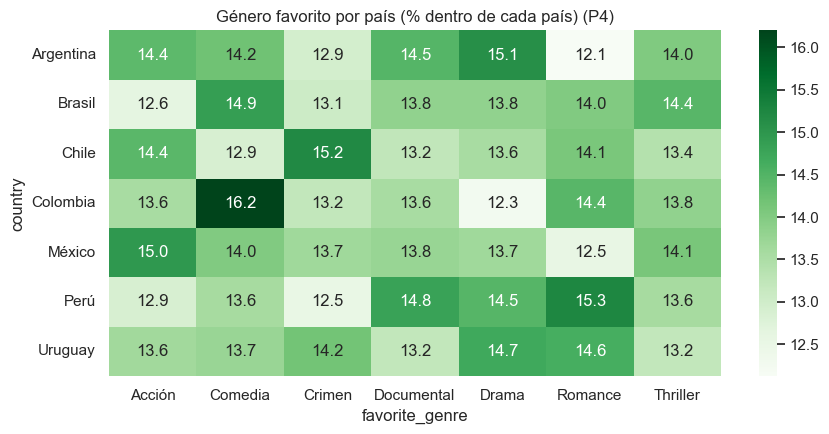

In [8]:
tabla = pd.crosstab(df["country"], df["favorite_genre"], normalize="index") * 100
tabla = tabla.drop(columns="Desconocido")
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(tabla, annot=True, fmt=".1f", cmap="Greens", ax=ax)
ax.set_title("Género favorito por país (% dentro de cada país) (P4)")
plt.tight_layout()
plt.show()

**Interpretación (P4):** la distribución de géneros es **homogénea entre países**: cada género representa
entre el 12 % y el 16 % en todos los mercados, sin preferencias regionales marcadas. Para el negocio,
un catálogo/promoción por género no necesitaría diferenciarse por país según estos datos.

## Síntesis del EDA

1. Consumo mensual asimétrico a la derecha; usuario típico ~770 min/mes (P1).
2. El **plan** es el gran diferenciador del consumo: la mediana se duplica de Básico a Premium,
   y el patrón se repite en los 7 países (P2).
3. La edad no se relaciona con el consumo (r ≈ 0) (P3).
4. Preferencias de género homogéneas entre países (P4).
5. Las variables numéricas están incorrelacionadas entre sí, lo que condiciona el PCA (P5).